🟢Sprint 1 (Importação dos dados): Realização da importação dos dados na plataforma Kaggle para a IDE VsCode ou Colab, onde  o script  será executado
https://www.kaggle.com/datasets/namespaiva/base-varejo?resource=download

Descrição da base de dados:
A base de dados Varejo é um recorte de 50.000 compras de 1.000 clientes realizadas em uma rede de supermercados no período de 2010 à 2022.

1. DATA: Data da compra;
2. CO_ID: Identificação do número de compra (número da nota fiscal);
3. CL_ID: Identificação do cliente (número do cliente);
4. CL_GENERO: Sexo biológico informado pelo cliente;
5. CL_EC: Estado civil do cliente:
    1: Casado ou união estával;
    2: Divorciado;
    3: Separado;
    4. Solteiro;
    5: Viúvo
6. CL_FHL: Número de filhos do cliente;
7. CL_SEG: Segmentação econômica do cliente (classe A, B ou C);
8. PR_ID: Código do produto (SKU) adquirido;
9. PR_CAT: Categoria do produto adquirido;
10. PR_NOME: Nome do produto adquirido.

In [76]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sbn
from itertools import combinations
from collections import Counter

caminho = os.path.join('database', 'Base Varejo.csv')
df_base_varejo = pd.read_csv(caminho, sep=";")
print(df_base_varejo.info())
df_base_varejo.head()


<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB
None


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


🟢Sprint 2 (Transformação de Strings, Integer e Float e Datetime): Desenvolvimento das funções de limpeza de texto, inteiros e decimais usando métodos e expressões regulares.

🟢Sprint 3 (Limpeza de Nulos e Duplicatas): Aplicação das condicionais e funções  para identificação e substituição de valores vazios e  de str para valores de data tipo datetime, na tabela de varejo. 


In [77]:
# Tirando as colunas vazias que vieram sobrando
df_base_varejo = df_base_varejo.dropna(axis=1, how='all')

# Ajustando a data e tratando aquele #N/D na categoria
df_base_varejo['DATA'] = pd.to_datetime(df_base_varejo['DATA'], format='%d/%m/%Y', errors='coerce')
df_base_varejo['PR_CAT'] = df_base_varejo['PR_CAT'].apply(lambda x: "Sem Categoria" if x == '#N/D' else x)

# Renomeando códigos de estado civil para palavras
ec_map = {
    '1': 'Casado ou união estável',
    '2': 'Divorciado',
    '3': 'Separado',
    '4': 'Solteiro',
    '5': 'Viúvo'
}
df_base_varejo['CL_EC'] = df_base_varejo['CL_EC'].astype(str).map(ec_map).fillna(df_base_varejo['CL_EC'])

# Tirar duplicadas e salvar
antes = df_base_varejo.shape[0]
df_base_varejo = df_base_varejo.drop_duplicates()
depois = df_base_varejo.shape[0]
print(f"Linhas removidas por duplicidade: {antes - depois}")

# Salvando o arquivo limpo (df_limpo.csv)
caminho_saida = os.path.join('database', 'df_limpo.csv')
df_base_varejo.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8')

print(f"\nBase limpa salva com sucesso em: {caminho_saida}")

print("Base carregada e limpa com sucesso.")
df_base_varejo.head()

Linhas removidas por duplicidade: 96553

Base limpa salva com sucesso em: database\df_limpo.csv
Base carregada e limpa com sucesso.


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,Solteiro,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,Solteiro,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,Solteiro,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,Solteiro,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,Solteiro,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


In [78]:
caminho_arquivo = os.path.join('database', 'df_limpo.csv')
df_limpo = pd.read_csv(caminho_arquivo, sep=';')
df = df_limpo
print(df.describe())

               CO_ID          CL_ID         CL_FHL          PR_ID
count  733447.000000  733447.000000  733447.000000  733447.000000
mean   459941.034680     499.643996       1.146049     115.037337
std    265431.394822     287.561653       1.416917      66.124263
min      1000.000000       1.000000       0.000000       1.000000
25%    232895.000000     254.000000       0.000000      58.000000
50%    456422.000000     498.000000       0.000000     115.000000
75%    690100.000000     746.000000       2.000000     172.000000
max    919822.000000    1000.000000       4.000000     229.000000


In [79]:
# avaliando os resultados dos valores únicos de cada coluna para limpeza 
# de texto e tratamento de dados faltantes
for coluna in df_limpo.columns:
    print(f"--- Valores únicos em: {coluna} ---")
    print(df_base_varejo[coluna].unique())
    print("\n") 


--- Valores únicos em: DATA ---
<DatetimeArray>
['2019-02-01 00:00:00', '2019-09-01 00:00:00', '2019-01-13 00:00:00',
 '2019-01-19 00:00:00', '2019-01-23 00:00:00', '2019-01-29 00:00:00',
 '2019-05-02 00:00:00', '2019-06-02 00:00:00', '2019-09-02 00:00:00',
 '2019-02-14 00:00:00',
 ...
 '2022-07-16 00:00:00', '2022-07-17 00:00:00', '2022-07-24 00:00:00',
 '2022-07-30 00:00:00', '2022-07-31 00:00:00', '2022-06-08 00:00:00',
 '2022-12-08 00:00:00', '2022-08-15 00:00:00', '2022-08-17 00:00:00',
 '2022-08-19 00:00:00']
Length: 333, dtype: datetime64[us]


--- Valores únicos em: CO_ID ---
[  1000   1040   1078 ... 919716 919770 919822]


--- Valores únicos em: CL_ID ---
[ 534  279  290  323  957   49  906  653  842  616  406  576  652  453
  829  251  397  438   69  608  423   53  886  624   94  428   72  493
  497  164  689   99  866  801  340   52  574  328  466  296  149  458
  776  746   45  798  709  796  878  888  246  433  545  943  429   56
  922  305  236  193  927  594  333  199  

🟢Sprint 4 (Estatística Descritiva): Aplicação das funções estatísticas para coletar parâmetros da coluna de Número de filhos do cliente.

In [80]:
#Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem, quartis)

coluna = 'CL_FHL'
resumo = {
    'Média': df_limpo[coluna].mean(),
    'Mediana': df_limpo[coluna].median(),
    'Moda': df_limpo[coluna].mode()[0],
    'Desvio Padrão': df_limpo[coluna].std(),
    'Mínimo': df_limpo[coluna].min(),
    'Máximo': df_limpo[coluna].max(),
    'Contagem': df_limpo[coluna].count()
}
estatisticas = df_limpo[coluna].describe()
print(estatisticas)
print()
# Transformar o dicionário em um DataFrame
resumo__estatisticas_df = pd.DataFrame(resumo, index=[0])
print(resumo__estatisticas_df)


count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64

      Média  Mediana  Moda  Desvio Padrão  Mínimo  Máximo  Contagem
0  1.146049      0.0     0       1.416917       0       4    733447


🟢Sprint 5 (Relatório e Documentação): Construção dos contadores do relatório final exibido no terminal, finalização do README.md com a reflexão teórica e submissão do link no AVA.


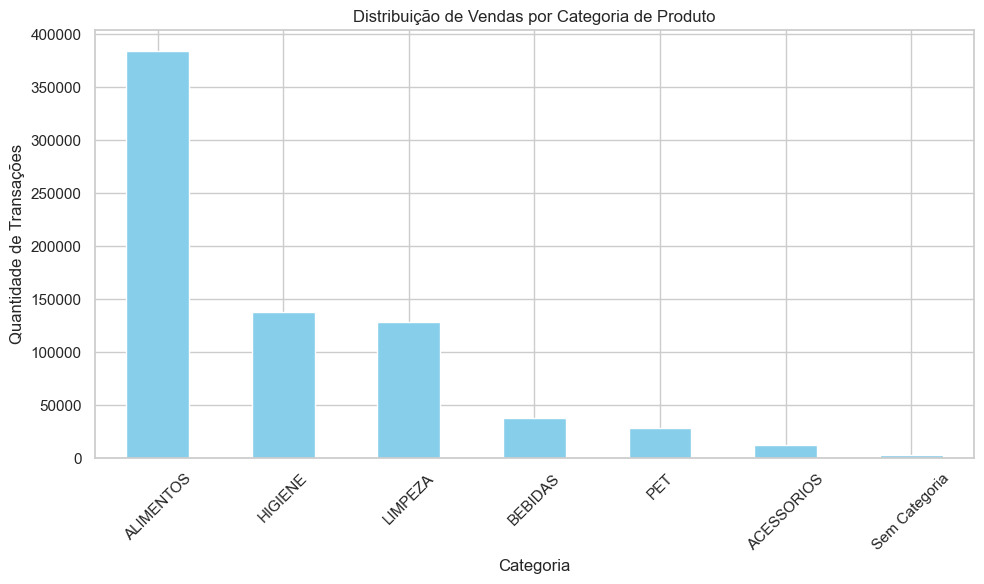

C:\Users\PP5RD\AppData\Local\Temp\ipykernel_28772\871210581.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(x='CL_GENERO', data=df_limpo, palette='viridis')


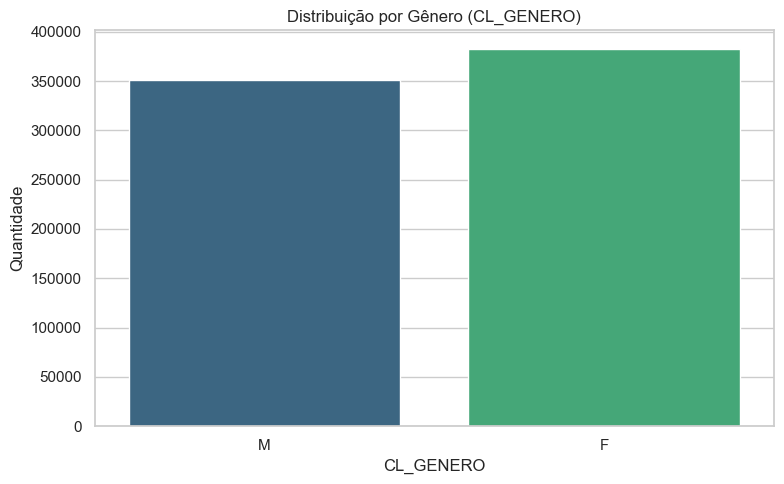

C:\Users\PP5RD\AppData\Local\Temp\ipykernel_28772\871210581.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(x='CL_EC', data=df_limpo, palette='magma')


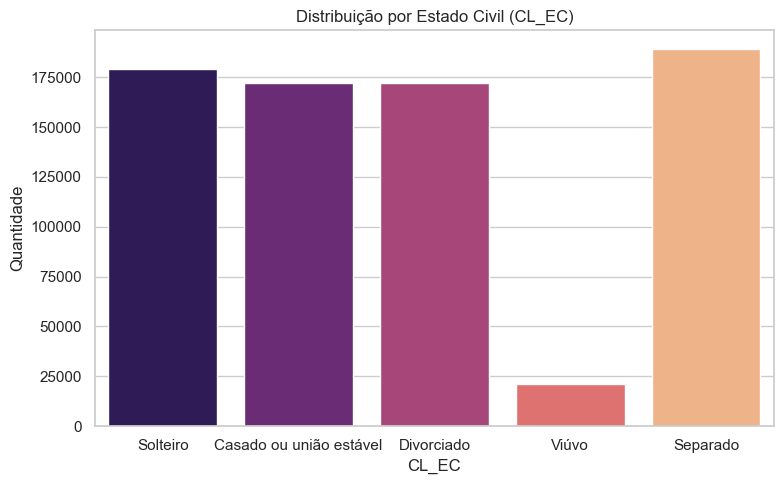

--- Insights da Sprint 3 ---
Total de categorias únicas: 7
Top 3 Categorias mais vendidas:
PR_CAT
ALIMENTOS    384197
HIGIENE      137702
LIMPEZA      128632
Name: count, dtype: int64


In [81]:
# Configuração de estilo para os gráficos
sbn.set_theme(style="whitegrid")

# 1. Análise de Frequência de Categorias (PR_CAT)
plt.figure(figsize=(10, 6))
df_limpo['PR_CAT'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribuição de Vendas por Categoria de Produto')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Transações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Perfil Demográfico: Gênero (Gráfico isolado)
plt.figure(figsize=(8, 5))
sbn.countplot(x='CL_GENERO', data=df_limpo, palette='viridis')
plt.title('Distribuição por Gênero (CL_GENERO)')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

# 3. Perfil Demográfico: Estado Civil (Gráfico isolado)
plt.figure(figsize=(8, 5))
sbn.countplot(x='CL_EC', data=df_limpo, palette='magma')
plt.title('Distribuição por Estado Civil (CL_EC)')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

# 4. Resumo textual das descobertas
print("--- Insights da Sprint 3 ---")
print(f"Total de categorias únicas: {df_limpo['PR_CAT'].nunique()}")
print("Top 3 Categorias mais vendidas:")
print(df_limpo['PR_CAT'].value_counts().head(3))

Colunas de tempo criadas.


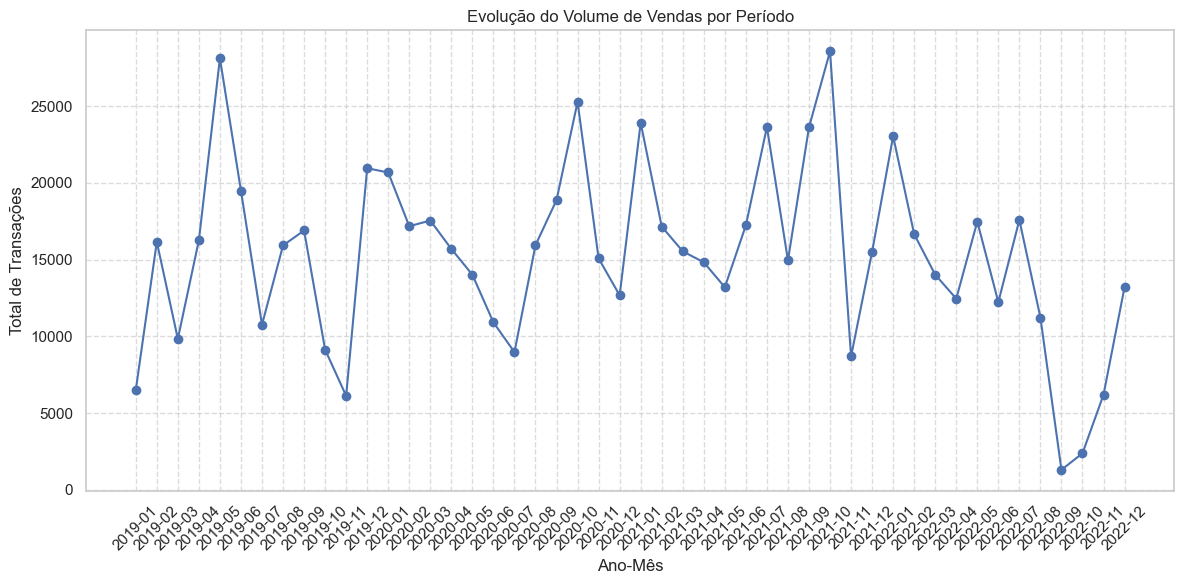

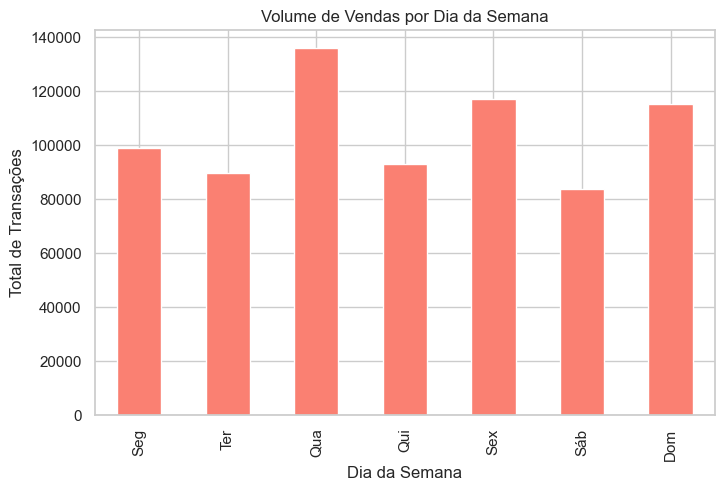

In [ ]:
# Agrupamento por tempo
# Vendas por Ano e Mês
#Convertendo a coluna DATA para o tipo datetime
df_limpo['DATA'] = pd.to_datetime(df_limpo['DATA'])

# 2. Agora você pode extrair as informações
df_limpo['MES'] = df_limpo['DATA'].dt.month
df_limpo['ANO'] = df_limpo['DATA'].dt.year
df_limpo['DIA_SEMANA'] = df_limpo['DATA'].dt.dayofweek

# Mapeando os dias
dias = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}
df_limpo['NOME_DIA'] = df_limpo['DATA'].dt.dayofweek.map(dias)

print("Colunas de tempo criadas.")

vendas_por_mes = df_limpo.groupby(['ANO', 'MES']).size().reset_index(name='QTD_VENDAS')
vendas_por_mes['PERIODO'] = vendas_por_mes['ANO'].astype(str) + '-' + vendas_por_mes['MES'].astype(str).str.zfill(2)

# 3. Gráfico de Evolução Temporal
plt.figure(figsize=(12, 6))
plt.plot(vendas_por_mes['PERIODO'], vendas_por_mes['QTD_VENDAS'], marker='o', linestyle='-', color='b')
plt.title('Evolução do Volume de Vendas por Período')
plt.xlabel('Ano-Mês')
plt.ylabel('Total de Transações')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Análise de Vendas por Dia da Semana
vendas_por_dia = df_limpo.groupby('NOME_DIA').size().reindex(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])

plt.figure(figsize=(8, 5))
vendas_por_dia.plot(kind='bar', color='salmon')
plt.title('Volume de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Total de Transações')
plt.show()


🟢Sobre os problemas na base:

⚠️Dados vazios (#N/D): Tem muita categoria marcada como #N/D, o que tá atrapalhando nossa análise de mercado. Precisamos ver com o pessoal de dados o que tá acontecendo	com esse registro.

⚠️Limpeza geral: A extração ainda precisa de um pente fino. Tem muita duplicata e campo nulo que pode enviesar o resultado, então precisamos criar uma rotina de higienização melhor.

⚠️Falta de tempo: A base hoj só mostra o volume total, mas não temos o histórico. Sem saber a sazonalidade, fica difícil prever o que vem por ai.

===============================================================================
🟢Principais conclusões:

⭐Foco em Alimentos: A maior parte das vendas vem de alimentos, o que mostra que o pessoal prioriza itens essenciais e compra com frequência.

⭐Segmentação por perfil: Percebemos que casados costumam comprar bem mais itens para casa, o que é um prato cheio para campanhas mais direcionadas.

⭐Mix de produtos: Usar o ranking de vendas ajudou a bater o olho e ver o que realmente traz faturamento, ficando mais fácil decidir promoções e o que repor no estoque.